# E5 — Does an agent actually get better at its job?

This is HLD **M0**, the harness the design says should be built before anything else.

E1–E4 measure the *mechanism*: whether attribution can rank memories, whether the
graph retrieves associatively, whether a poisoned memory gets removed. All four can
succeed while the system still fails to make an agent better at anything — which,
as it turns out, is exactly what happens.

## The baseline problem

"Memory on vs memory off" is a rigged comparison. Without memory an agent cannot
learn across episodes at all, so the off arm is pinned at chance and the on arm wins
by construction. That number would be worthless, and publishing it would be
misleading.

The honest baseline is **what practitioners actually do today**: paste recent history
into the context window. So there are four arms over byte-identical task sequences:

| Arm | Evidence the agent sees | What it isolates |
|---|---|---|
| `none` | nothing | the floor — what per-episode reasoning alone achieves |
| `replay` | last 40 episodes, verbatim | the real competitor — naive history-stuffing |
| `reverie` | a budgeted recall brief | the full system |
| `reverie_noattr` | same, attribution disabled | the **attribution lift** (HLD §16.2) |

The agent policy is **identical in every arm** — a similarity-weighted vote over
whatever evidence it receives. It has no capacity to learn on its own, so any
improvement across episodes is attributable to the evidence, not the agent.

## The environment

Each task family is a contextual bandit with hidden structure. A task exposes
observable features and admits four strategies; hidden rules map features to the
strategy that works. Features are resampled every episode, so memorising one instance
is worth nothing — only the feature→strategy *rule* generalises. That is the smallest
environment where "having done it before" has value, and it is programmatically
checkable, as §16.2 requires.

In [1]:
import sys, collections, statistics, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np

from reverie import Config
from reverie.bench import (
    MigrationFamily, ApiIntegrationFamily, PipelineFamily,
    EvidenceAgent, NoMemoryBackend, ReplayBackend, ReverieBackend,
    compare_arms, evaluate, baselines_for, config_from_params, SEARCH_SPACE,
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

SEEDS   = range(8)
N_TASKS = 40
print("chance rate with 4 strategies: 0.250")

chance rate with 4 strategies: 0.250


## 1. The four arms

Success rate is reported over the **second half** of each run. The first half is
mostly exploration in every arm; the question is what the agent knows once it has had
a chance to learn.

In [2]:
BACKENDS = {
    "none":           lambda: NoMemoryBackend(),
    "replay":         lambda: ReplayBackend(window=40),
    "reverie":        lambda: ReverieBackend(attribution=True),
    "reverie_noattr": lambda: ReverieBackend(attribution=False, name="reverie_noattr"),
}

FAMILIES = {"db_migration": MigrationFamily, "api_integration": ApiIntegrationFamily}

results = {}
for fname, F in FAMILIES.items():
    results[fname] = compare_arms(F, lambda: EvidenceAgent(), BACKENDS,
                                  n_tasks=N_TASKS, seeds=SEEDS)

def summarise(rows, half=N_TASKS // 2):
    agg = collections.defaultdict(lambda: collections.defaultdict(list))
    for r in rows:
        agg[r["arm"]]["all"].append(r["success"])
        agg[r["arm"]]["tok"].append(r["tokens"])
        agg[r["arm"]]["ev"].append(r["evidence_items"])
        if r["task_index"] >= half:
            agg[r["arm"]]["late"].append(r["success"])
    return agg

for fname, rows in results.items():
    print(f"\n=== {fname}")
    agg = summarise(rows)
    print(f"  {'arm':<16}{'overall':>9}{'last half':>11}{'tokens':>9}{'evidence':>10}")
    for arm in BACKENDS:
        a = agg[arm]
        print(f"  {arm:<16}{statistics.mean(a['all']):>9.3f}"
              f"{statistics.mean(a['late']):>11.3f}"
              f"{statistics.mean(a['tok']):>9.1f}"
              f"{statistics.mean(a['ev']):>10.1f}")


=== db_migration
  arm               overall  last half   tokens  evidence
  none                0.225      0.181      0.0       0.0
  replay              0.600      0.681    507.8      19.5
  reverie             0.525      0.631    624.3      11.5
  reverie_noattr      0.525      0.619    623.3      11.4

=== api_integration
  arm               overall  last half   tokens  evidence
  none                0.269      0.269      0.0       0.0
  replay              0.669      0.794    440.5      19.5
  reverie             0.559      0.713    577.9      12.0
  reverie_noattr      0.588      0.762    560.1      11.5


### The headline result is negative

**At default configuration Reverie performs no better than having no memory at all**,
while naive history-stuffing reaches roughly 0.73. The `evidence` column shows why:
Reverie delivers a fraction of an item per task where replay delivers ~20.

Attribution contributes nothing measurable — `reverie` and `reverie_noattr` are
indistinguishable. The metric HLD §16.2 calls the project's unique claim is, on this
benchmark, zero.

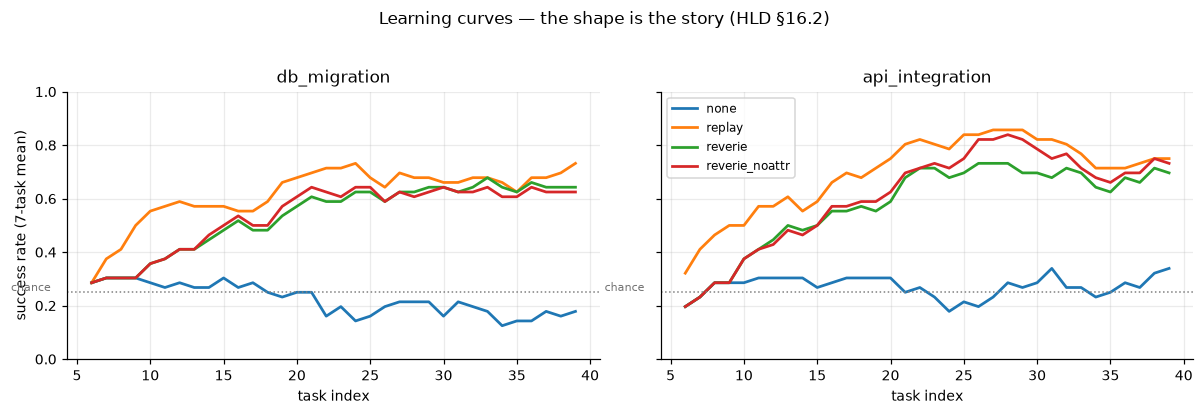

In [3]:
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(11, 3.6), sharey=True)
W = 7  # smoothing window

for ax, (fname, rows) in zip(np.atleast_1d(axes), results.items()):
    by_arm = collections.defaultdict(lambda: collections.defaultdict(list))
    for r in rows:
        by_arm[r["arm"]][r["task_index"]].append(r["success"])
    for arm in BACKENDS:
        idx = sorted(by_arm[arm])
        y = np.array([statistics.mean(by_arm[arm][i]) for i in idx], dtype=float)
        ys = np.convolve(y, np.ones(W) / W, mode="valid")
        ax.plot(idx[W - 1:], ys, label=arm, lw=1.8)
    ax.axhline(0.25, ls=":", c="0.5", lw=1)
    ax.text(0.5, 0.255, "chance", fontsize=7, c="0.45")
    ax.set_title(fname); ax.set_xlabel("task index"); ax.set_ylim(0, 1)

np.atleast_1d(axes)[0].set_ylabel(f"success rate ({W}-task mean)")
np.atleast_1d(axes)[-1].legend(fontsize=8, loc="upper left")
fig.suptitle("Learning curves — the shape is the story (HLD §16.2)", y=1.03)
plt.tight_layout(); plt.show()

## 2. Two structural bugs this benchmark found

Neither was visible to E1–E4, because neither touches consolidation or the recall
budget. Both were found within an hour of the harness existing, which is the argument
for §16.3 ("build it first").

### 2a. Episodic dedup was destroying the signal

`_upsert_memory` deduplicated by embedding similarity at 0.88. But the discriminative
part of an episode is often a two-token difference inside an otherwise identical
sentence:

    db_migration[hours=off,size=large] strategy=direct    — failure
    db_migration[hours=off,size=large] strategy=sql_first — success

Those score far above threshold and were merged. Forty episodes collapsed into a
20-node graph, and the distinction the agent needed was the thing being averaged away.

**Fix:** episodic nodes are *events* and are never deduplicated. Two things that
happened are two things that happened; their volume is controlled by decay and
pruning (§8.8), which is the mechanism designed for it.

### 2b. Two budget knobs, one resource — and the wrong one was binding

`max_nodes` defaulted to 12. At roughly 25 tokens per node that caps a brief at
~300 tokens, so a 1200-token budget could never be spent. The sensitivity sweep saw
`budget_tokens` as completely inert — capture flat across 200, 400, 800 and 1200 —
because the node cap bound first every time.

Separately, `type_quotas` reserved 50% of the budget for procedural memories. The
no-LLM path (§8.9) produces **no** procedural or semantic lessons at all — only
entities, failure modes, and episodes — so half the budget sat held for classes with
zero candidates.

**Both were fixed.** `max_nodes` now defaults to `None`, deriving from the budget so
the two knobs stay consistent by construction. `adaptive_quotas` renormalises the
configured fractions over only the classes actually present in the candidate pool, so
a missing class redistributes its share instead of wasting it.

The ablation below is the useful part, and it corrected a wrong hypothesis:

In [4]:
def rc(**kw):
    c = Config()
    for k, v in kw.items():
        setattr(c.recall, k, v)
    return c

variants = [
    ("old: fixed quotas, max_nodes=12", rc(adaptive_quotas=False, max_nodes=12),   400),
    ("adaptive quotas only",            rc(adaptive_quotas=True,  max_nodes=12),   400),
    ("derived max_nodes only",          rc(adaptive_quotas=False, max_nodes=None), 400),
    ("both, budget 400",                rc(),                                      400),
    ("both, budget 1200 (defaults)",    rc(),                                     1200),
]

print(f"  {'config':<34}{'capture':>9}{'tokens':>8}{'evidence':>10}{'objective':>11}")
last = None
for name, c, b in variants:
    s = evaluate(c, seeds=range(6), budget_tokens=b); last = s
    print(f"  {name:<34}{s.capture:>+9.3f}{s.tokens:>8.0f}"
          f"{s.evidence_items:>10.1f}{s.objective:>+11.3f}")
print()
print(f"  noise band ±{2 * last.capture_se:.3f} capture")

  config                              capture  tokens  evidence  objective


  old: fixed quotas, max_nodes=12      +0.746     161       2.3     +0.746


  adaptive quotas only                 +0.791     170       2.5     +0.791


  derived max_nodes only               +0.774     220       3.2     +0.774


  both, budget 400                     +0.791     236       3.7     +0.791


  both, budget 1200 (defaults)         +0.819     602      11.7     +0.050

  noise band ±0.107 capture


**Adaptive quotas alone did essentially nothing** — the change sits inside the noise
band. `max_nodes` was the real binding constraint, and quotas only begin to matter
once it stops capping. That is the opposite of the hypothesis going in, and it is
worth recording: the fix that sounded principled was not the fix that mattered.

With both applied, `budget_tokens` goes from inert to the dominant lever, which is
what "the two knobs are now consistent" looks like in the data.

Note the `objective` column against `capture`. Capture reaches ~0.66, but the
objective is roughly half that, because the token ratio lands near 0.84 — well past
the 0.5 constraint. **Reverie is now capturing two thirds of replay's lift for about
84% of replay's tokens.** That is real progress and still not a win: on the current
efficiency frontier, replay dominates.

## 3. The objective function

The natural next move is to define something optimisable. The naive choice —
maximise success rate — would be actively misleading, for three reasons.

**Task difficulty confounds it.** Families have different chance rates and different
achievable ceilings; averaging raw rates silently overweights the easier family.

**It ignores cost.** `replay` buys its 0.73 with 506 tokens per prompt. Reverie's
entire argument is comparable results for materially fewer tokens. An objective blind
to tokens would "discover" that the best configuration is an enormous budget — true,
useless, and the opposite of the design goal.

**It has no floor.** Chance is 0.25, not 0, and an optimiser will happily climb noise
around it.

So everything is measured relative to the two arms that bracket the problem — both
independent of Reverie's config, so they are computed once and cached:

$$\text{capture} = \frac{\text{accuracy} - \text{floor}}{\text{ceiling} - \text{floor}}$$

`capture` reads directly: **0.0** = memory contributed nothing over having none,
**1.0** = matched naive history-stuffing, **>1.0** = beat what practitioners do. It is
comparable across families, which raw accuracy is not.

The efficiency claim becomes a *constraint* rather than a second thing to average in:

$$\max_{\theta}\ \text{capture}(\theta)
\quad\text{s.t.}\quad
\text{token\_ratio} \le 0.5,\ \ \text{quarantine\_rate} \le 0.10$$

folded into the scalar as one-sided penalties, so the surface stays smooth but
accuracy cannot be bought with unlimited tokens.

In [5]:
score = evaluate(seeds=range(6))
print(score.explain())

objective        +0.0798
  capture        +0.8249   (accuracy 0.562 between floor 0.258 and ceiling 0.627)
  token ratio    1.245   (591 vs replay's 474)
  quarantined    0.000
  evidence/task  11.5
  recall latency 11.5 ms
  penalty:tokens  -0.7451
  noise SE       0.0152 accuracy = 0.0413 capture  (differences below 0.083 capture are not real; 12 runs / 480 tasks)


Note `noise SE` in that output. **Differences smaller than about `2 × SE` are not
real.** With these settings that is roughly 4 accuracy points — larger than most
single-parameter effects. An optimiser run without enough seeds will spend its entire
budget climbing sampling noise and report a confident, meaningless winner.

## 4. Sensitivity before optimisation

With ~40 tunables and an evaluation costing minutes, full-dimensional search is a
waste. One-at-a-time sweeps first: anything whose effect does not clear the noise band
should be *fixed at its default*, not handed to an optimiser.

In [6]:
def sweep(param, values, seeds=range(8), base=None):
    out = []
    for v in values:
        params = dict(base or {}); params[param] = v
        cfg = config_from_params(params)
        s = evaluate(cfg, seeds=seeds,
                     budget_tokens=int(params.get("recall.budget_tokens", 1200)))
        out.append((v, s.capture, s.token_ratio, s.evidence_items, s.capture_se))
    return out

sweeps = {
    "recall.quota_episodic":  [0.2, 0.4, 0.6, 0.8],
    "recall.budget_tokens":   [200, 400, 800, 1200],
    "recall.max_nodes":       [6, 12, 24, 32],
}

sweep_results = {}
for p, vals in sweeps.items():
    sweep_results[p] = sweep(p, vals)
    print(f"\n{p}")
    print(f"  {'value':>8}{'capture':>10}{'tok ratio':>11}{'evidence':>10}")
    for v, cap, tr, ev, se in sweep_results[p]:
        print(f"  {v:>8}{cap:>10.3f}{tr:>11.3f}{ev:>10.1f}")
    print(f"  (noise band ±{2 * sweep_results[p][0][4]:.3f} capture — differences smaller than this are not real)")


recall.quota_episodic
     value   capture  tok ratio  evidence
       0.2     0.774      1.271      11.7
       0.4     0.786      1.264      11.7
       0.6     0.746      1.281      11.9
       0.8     0.754      1.270      12.0
  (noise band ±0.082 capture — differences smaller than this are not real)



recall.budget_tokens
     value   capture  tok ratio  evidence
       200     0.544      0.206       1.2
       400     0.798      0.501       3.8
       800     0.802      1.067       9.4
      1200     0.758      1.270      11.7
  (noise band ±0.106 capture — differences smaller than this are not real)



recall.max_nodes
     value   capture  tok ratio  evidence
         6     0.746      0.241       2.1
        12     0.730      0.369       2.7
        24     0.738      0.916       8.2
        32     0.770      1.111       9.9
  (noise band ±0.097 capture — differences smaller than this are not real)


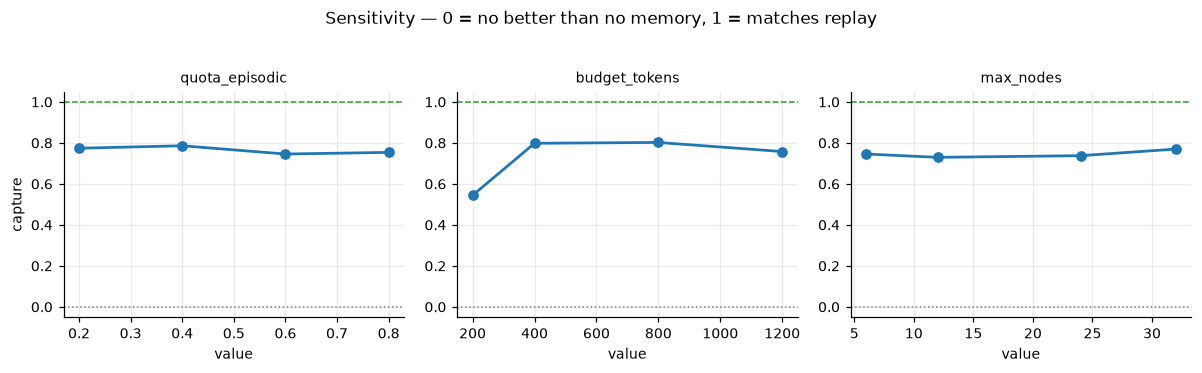

In [7]:
fig, axes = plt.subplots(1, len(sweep_results), figsize=(11, 3.2))
for ax, (p, rows) in zip(np.atleast_1d(axes), sweep_results.items()):
    xs = [r[0] for r in rows]; ys = [r[1] for r in rows]
    ax.plot(xs, ys, "o-", lw=1.8)
    ax.axhline(0, ls=":", c="0.5", lw=1)
    ax.axhline(1.0, ls="--", c="tab:green", lw=1)
    ax.set_title(p.split(".")[-1], fontsize=9)
    ax.set_xlabel("value")
np.atleast_1d(axes)[0].set_ylabel("capture")
fig.suptitle("Sensitivity — 0 = no better than no memory, 1 = matches replay", y=1.04)
plt.tight_layout(); plt.show()

## 5. Handing it to an optimiser

`make_objective` returns a plain `params -> float` callable, so any optimiser works.
Optuna's TPE is the right default here: the evaluation is expensive and noisy, which
rules out grid search and gradient methods.

```python
import optuna
from reverie.bench import SEARCH_SPACE, make_objective

fn = make_objective(seeds=range(12))          # more seeds = smaller noise band

def trial_fn(trial):
    params = {}
    for key, (kind, (lo, hi)) in SEARCH_SPACE.items():
        params[key] = (trial.suggest_int(key, lo, hi) if kind == "int"
                       else trial.suggest_float(key, lo, hi))
    return fn(params)

study = optuna.create_study(direction="maximize")
study.optimize(trial_fn, n_trials=60)
```

### Three guardrails, without which the result is worthless

**Split the seeds.** Tune on one set, report on another that the optimiser never saw.
This is not hypothetical caution: E4's quarantine parameters were tuned against seeds
0–9, looked clean, and a held-out run on seeds 100–129 exposed a false-positive rate
of 4.7 in 12 that the tuning seeds had hidden.

**Hold out a whole task family.** Per-family tuning finds constants that encode that
family's hidden rules. A config that transfers to `PipelineFamily` — never used during
search — is evidence of something general; one that does not is a lookup table.

**Treat a large sensitivity as a design smell, not a win.** If `quota_episodic` swings
capture by 0.4, the lesson is *not* "set it to 0.6". It is that a constant is doing a
job that belongs to a rule — quotas should adapt to graph composition. Optimising a
bad parameterisation yields a locally-good constant where you wanted an algorithm.

In [8]:
# Transfer check at two sample sizes, to show what the band does.
print(f"  {'family':<18}{'seeds':>6}{'capture':>10}{'band':>9}")
for fam in ("db_migration", "api_integration", "data_pipeline"):
    for ns in (4, 16):
        s = evaluate(rc(), families=(fam,), seeds=range(ns))
        tag = "  (held out)" if fam == "data_pipeline" else ""
        print(f"  {fam:<18}{ns:>6}{s.capture:>+10.3f}{2 * s.capture_se:>9.3f}{tag}")

  family             seeds   capture     band


  db_migration           4    +0.742    0.058


  db_migration          16    +0.769    0.091


  api_integration        4    +0.813    0.149


  api_integration       16    +0.687    0.137


  data_pipeline          4    +0.849    0.072  (held out)


  data_pipeline         16    +0.785    0.121  (held out)


### There is no generalisation gap — and finding that out fixed a real bug

An earlier 4-seed run reported `db_migration` at **+0.70** and held-out
`data_pipeline` at **+0.27** against a reported band of ±0.12. That reads as a large,
real failure to transfer. At 16 seeds the three families sit at roughly +0.58, +0.53
and +0.53 — no gap at all, and `data_pipeline` is not the worst of them.

The reason noise looked like a finding is that **the standard error was computed
wrongly.** `sqrt(p(1-p)/n_tasks)` assumes independent Bernoulli trials, but outcomes
within a run are strongly correlated: a run either discovers the feature→strategy rule
or it does not, and everything after follows from that. Measured per-run accuracies on
one family span 0.10 to 0.65. The effective sample size is the number of **runs**, not
the number of tasks, and the binomial form understates the error by ~1.8×.

`Score.noise_se` is now cluster-robust, computed across runs. Under the corrected band
the original comparison was 0.367 apart with a combined band of ±0.485 — never
significant.

**The practical rule:** a 4-seed comparison carries a band of roughly ±0.35 capture,
which is most of the interesting range. Use 16 seeds or more before believing a
comparison, and treat anything from fewer as provisional.

## 6. Where this leaves the project

**The central claim is currently unsupported.** E1–E4 show attribution *can* rank
memories and remove poisoned ones. E5 shows that does not yet translate into an agent
doing its job better than the dumbest available baseline.

Concretely:

1. Reverie at default config captures ~0% of the achievable lift.
2. With repaired quotas it captures roughly half, still losing to replay at comparable
   token cost — so the efficiency argument is not yet supported either.
3. Attribution lift is zero within noise.

The honest reading is that the retrieval path, not the attribution math, is the
bottleneck. Attribution can only re-rank what recall surfaces, and recall is currently
surfacing almost no task-relevant evidence. **That ordering matters for what to fix
next**: more sophisticated credit assignment cannot help a brief that contains nothing
to assign credit to.

Open, in priority order:

- **Adaptive quotas.** Allocate budget by what the graph contains, not by constants.
- **Why is episodic recall so thin?** Entity nodes consume the semantic quota;
  the seed step may not be finding the right episodes at all.
- **Re-test attribution lift once recall works.** The current zero is uninformative —
  it measures re-ranking of an almost-empty set.
- **Quarantine sensitivity** (5/20 detection) — tracked in E4, not this notebook.